# Sentiment Analysis on IMDB Dataset 2026

In [1]:
# =======================
# Standard Libraries
# =======================
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# =======================
# Data & Numerical
# =======================
import pandas as pd
import numpy as np

# =======================
# Visualization
# =======================
import matplotlib.pyplot as plt
import seaborn as sns

# =======================
# NLP Libraries
# =======================
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import re

# =======================
# Scikit-learn (ML)
# =======================

# Model Selection
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =======================
# Deep Learning (TensorFlow)
# =======================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-04-23 11:41:36.202604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776944496.405091      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776944496.464513      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776944496.941777      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776944496.941818      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776944496.941821      22 computation_placer.cc:177] computation placer alr

In [2]:
train = pd.read_csv('/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/train.csv')
test = pd.read_csv('/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/test.csv')
val = pd.read_csv('/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/val.csv')

In [3]:
train.head()

,review,sentiment
0,Just a note to add to the above comment. Fear ...,positive
1,one of the worst films i have seen to date. Pa...,negative
2,Crossfire is one of those films from the Forti...,positive
3,The film begins with people on Earth discoveri...,negative
4,"This was a pretty good episode. Though no ""Tra...",positive


In [4]:
test.head()

,review
0,I read the running man from Kings books as Bac...
1,A noted cinematic phenomenon of the late eight...
2,THE ALARMIST is so abysmally scripted that you...
3,I wasn't planning on watching wasted when I sa...
4,What a piece of junk this movie was. The premi...


In [5]:
val.head()

,review,sentiment
0,The material is poor....the script's dreadful....,negative
1,"Bo is Jane Parker, whose long-lost anthropolog...",negative
2,After the reasonably successful MASTI which wa...,negative
3,Wildman head counselor Tripper Harrison (Bill ...,positive
4,This HAS to be the worst movie I've ever attem...,negative


In [6]:
print(train.shape)
print(test.shape)
print(val.shape)

(35000, 2)
(7500, 1)
(7500, 2)


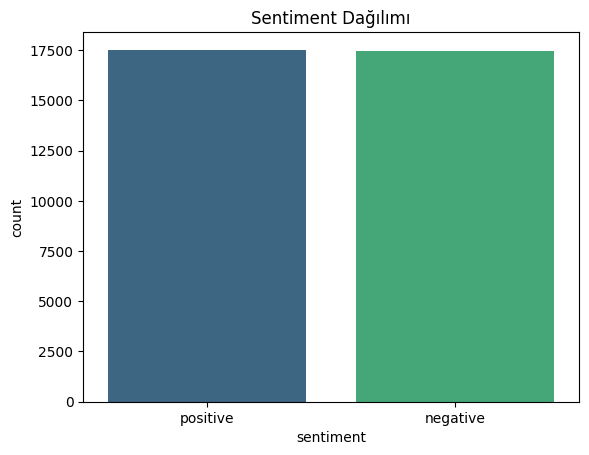

In [7]:
# Sentiment Distribution
sns.countplot(x=train['sentiment'], hue=train['sentiment'], palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

In [8]:
# positive/negative -> 1/0

sentiment_map = {'positive': 1, 'negative': 0}

train['label'] = train['sentiment'].map(sentiment_map)
val['label']   = val['sentiment'].map(sentiment_map)

In [9]:
#Cleaning df
def clean_text(df, col='review'):
    df[col] = df[col].str.lower()                              # küçük harf
    df[col] = df[col].str.replace('<.*?>', '', regex=True)     # HTML tagları (<br/>)
    df[col] = df[col].str.replace('[^\w\s]', '', regex=True)   # noktalama
    df[col] = df[col].str.replace('\d+', '', regex=True)       # rakamlar
    df[col] = df[col].str.replace('\n', '', regex=True)        # satır sonu
    df[col] = df[col].str.replace('\r', '', regex=True)        # enter
    return df

train = clean_text(train)
val   = clean_text(val)
test  = clean_text(test)

print(train['review'][0])

just a note to add to the above comment fear of a black hat doesnt have the criminal whos image has been ripped off by the band thats in cb easily confused as the two films are so similar but black hat is vastly the superior of the two yeah


In [10]:
#Stopwords + Lemmatization
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
#Vectorization
x_train = train['review']
y_train = train['label']

x_val = val['review']
y_val = val['label']

x_test = test['review']


vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')

x_train = vect.fit_transform(x_train)
x_val   = vect.transform(x_val)
x_test  = vect.transform(x_test)

In [12]:
print("Train shape:", x_train.shape)

Train shape: (35000, 162529)


In [13]:
# Model
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
# Tahmin
y_pred = model.predict(x_val)

In [15]:
# Sonuçlar
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=['negative', 'positive']))

Accuracy: 0.8796
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      3727
    positive       0.88      0.88      0.88      3773

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



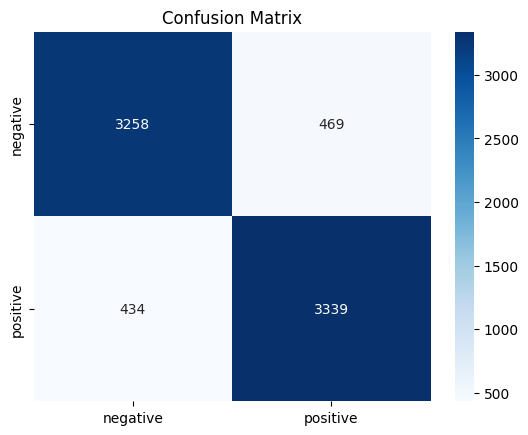

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title("Confusion Matrix")
plt.show()

In [17]:
# Test tahmini
test_pred = model.predict(x_test)

In [18]:
submission = pd.DataFrame({
    'ReviewId': range(1, len(test_pred) + 1), 
    'Label': test_pred.astype(int)             
})

In [19]:
submission.head(10)

,ReviewId,Label
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0
5,6,0
6,7,1
7,8,0
8,9,0
9,10,1


In [20]:
submission.to_csv('submission.csv', index=False)